### A/B Testing: A Practical Walkthrough with a Simulated Case¶


In this notebook we'll go over the process of analysing an A/B test with a simulated dataset. Typically an A/B Test a multiple step experimentation starting with formulating a hypothesis, testing it, checking its statistically and practically significance and finally interpreting results. For our data, we'll use a dataset from Kaggle which contains the results of an A/B test on what seems to be 2 different variants of a button (old_design vs. new_design). Here's what we'll do:

Designing our experiment
Collecting and preparing the data
Visualising the results
Testing the hypothesis
Drawing conclusions
To make it a bit more realistic, here's a potential case for our experimentation:

Let's imagine you work on the product team at a medium-sized online e-commerce business. The UX designer worked really hard on a new version of the check-out button, with the objective that it will lead to a higher conversion rate(or in simpler terms: will increase the revenue). The product manager told you that the current conversion rate is about 3.0% on average throughout the year, and that the team would be happy with an increase of 1.5%, meaning that the new design will be launched if it raises the conversion rate to 4.5%.

Ahead of deploying the change, the team would be more comfortable testing it on a small number of users(determined by power analysis) to see how it performs, so you suggest running an A/B test on a subset of your user base users(out of the 20k data collected say).


### 1. Designing our experiment¶


## Formulating a hypothesis

Firstly, we need to formulate a hypothesis at the start of our project. This will make sure our interpretation of the results is correct as well as rigorous.

Given we don't know if the new design will perform better or worse (or the same) as our current design, we'll choose a **two-tailed test**:

\[
H_0 : p = p_0
\]

\[
H_a : p != p_0
\]

where \( p \) and \( p_0 \) stand for the conversion rate of the new and old design, respectively.

We'll also set a confidence level of 95%:

\[
\alpha = 0.05
\]

The \( \alpha \) value is a threshold we set, by which we say: if the probability of observing a result as extreme or more extreme (the **p-value**) is lower than \( \alpha \), then we reject the null hypothesis.

Since our \( \alpha = 0.05 \) (indicating a 5% probability), our confidence level \( (1-\alpha) \) is 95%.

Don't worry if you are not familiar with the above. All this really means is that whatever conversion rate we observe for our new design in our test, we want to be 95% confident it is statistically different from the conversion rate of our old design before we decide to reject the null hypothesis \( H_0 \).

---

## Choosing the variables

For our test, we'll need two groups:

- **A control group** – They will be shown the old design
- **A treatment (or experimental) group** – They will be shown the new design

This will be our **independent variable**.

The reason we have two groups, even though we know the baseline conversion rate, is that we want to control for other variables that could affect our results, such as seasonality.

By having a control group, we can directly compare their results to the treatment group, because the only systematic difference between the groups is the design of the product page. We can therefore attribute any differences in results to the designs.

For our **dependent variable** (what we are trying to measure), we are interested in capturing the conversion rate.

A way we can code this is by assigning each user session a binary variable:

- **0** – The user did not buy the product during this session
- **1** – The user bought the product during this session

This way, we can easily calculate the mean for each group to get the conversion rate of each design.

---

## Choosing a sample size

It is important to note that since we won't test the whole user base (our population), the conversion rates we get will only be estimates of the true rates.

The number of people (or user sessions) we decide to include in each group will affect the precision of our estimated conversion rates:

- The larger the sample size, the more precise our estimates
- Larger samples lead to smaller confidence intervals
- Larger samples increase the chance of detecting a difference between groups, if one exists

On the other hand, the larger our sample gets, the more expensive and impractical the study becomes.

So how many people should we have in each group?

The sample size we need is estimated through something called **power analysis**, and it depends on a few factors:

- **Power of the test** \( (1-\beta) \) – the probability of finding a statistical difference when one is actually present. This is usually set to **0.8**
- **Alpha value** \( \alpha \) – the critical value we set earlier to **0.05**
- **Effect size** – how big of a difference we expect between the conversion rates

Since our team would be happy with a difference of **1.5%**, we can use **3.0%** and **4.5%** to calculate the expected effect size.

Luckily, Python can handle these calculations for us.

In [4]:
# Packages imports
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.stats.api as sms
import scipy.stats as stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from math import ceil

%matplotlib inline

In [5]:
effect_size = sms.proportion_effectsize(0.03, 0.045) # Calculating effect size based on our expected rates
required_n = sms.NormalIndPower().solve_power(
effect_size, 
power = 0.8,
alpha = 0.05,
ratio = 1
)

n = ceil(required_n)
n 


2494

We would need at least 2494 observations for each group,i.e., 4988 in total.

Having set the power parameter to 0.8 in practice means that if there exists an actual difference in conversion rate between our designs, assuming the difference is the one we estimated (3.0% vs. 4.5%), we have about 80% chance to detect it as statistically significant in our test with the sample size we calculated.

### 2. Load the Data 

In [30]:
df = pd.read_csv("../data/ab_data.csv")
df.head()

,User_ID,Variant,Clicks,Conversions
0,2721,A,3,0
1,2241,A,2,0
2,9808,A,16,0
3,3804,A,3,0
4,4391,A,9,0


In [31]:
#Basic Structure 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   User_ID      20000 non-null  int64 
 1   Variant      20000 non-null  object
 2   Clicks       20000 non-null  int64 
 3   Conversions  20000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 625.1+ KB


In [32]:
#Duplicate_users 

df['User_ID'].nunique()

20000

In [34]:
#Check Gorup Sizes 

control_size = len(df[df['Variant'] == 'A'])
treatment_size = len(df[df['Variant'] == 'B'])

print(f"Control group size: {control_size}")
print(f"Treatment group size: {treatment_size}")

Control group size: 10000
Treatment group size: 10000


Counts how many observations belong to:

group A = control

group B = treatment

Why this matters

You want the groups to be balanced.
If one group is much larger, the experiment may be biased.

In [35]:
# Total conversions per group

conversions_counts = df.groupby('Variant')['Conversions'].sum()
conversions_counts 

Variant
A    270
B    422
Name: Conversions, dtype: int64

### 2. Sampling

Now that the data is clean, I will randomly sample the required number of observations from each group.

This is done only for practice, since the full dataset already contains enough users.

In [36]:
control_sample = df[df['Variant'] == 'A'].sample(n=n, random_state=22)
treatment_sample = df[df['Variant'] == 'B'].sample(n=n, random_state=22)

ab_test = pd.concat([control_sample, treatment_sample], axis=0)
ab_test.reset_index(drop=True, inplace=True)

ab_test.head()

,User_ID,Variant,Clicks,Conversions
0,9150,A,5,0
1,926,A,4,0
2,7648,A,9,0
3,5625,A,8,0
4,9902,A,19,0


What this does

randomly picks n rows from group A

randomly picks n rows from group B

combines them into one dataframe called ab_test

Why random_state=22?

It makes the sampling reproducible.
That means if you run it again, you get the same rows.

In [37]:
# Check sampled group sizes

ab_test['Variant'].value_counts()

Variant
A    2494
B    2494
Name: count, dtype: int64

In [38]:
# Calculate sample conversion statistics

conversion_rates = ab_test.groupby('Variant')['Conversions']

std_p = lambda x: np.std(x, ddof=0)
se_p = lambda x: stats.sem(x, ddof=0)

conversion_summary = conversion_rates.agg(['mean', std_p, se_p])
conversion_summary.columns = ['conversion_rate', 'std_deviation', 'std_error']

conversion_summary

,conversion_rate,std_deviation,std_error
Variant,,,
A,0.024860,0.155697,0.003118
B,0.042903,0.202638,0.004058


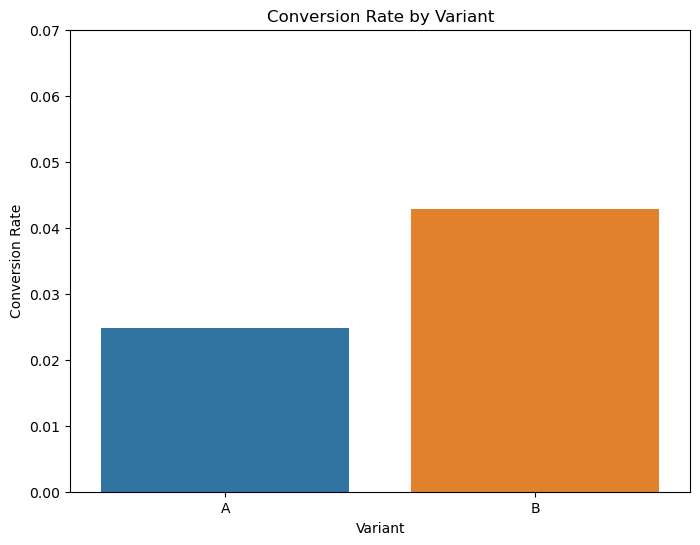

In [39]:
# Visualize conversion rates

plt.figure(figsize=(8, 6))
sns.barplot(x=ab_test['Variant'], y=ab_test['Conversions'], errorbar=None)

plt.ylim(0, 0.07)
plt.title('Conversion Rate by Variant')
plt.xlabel('Variant')
plt.ylabel('Conversion Rate')
plt.show()

In [ ]:
# Hypothesis testing using z-test